# Machine Learning in Python for Neuroimaging

William20260605

# Scikit-learn: Classification

In [1]:
import sklearn
import numpy as np
from matplotlib import pyplot as plt

In [2]:
from sklearn.datasets import load_iris
iris = load_iris()
print(iris.data.shape)

(150, 4)


## Classification with Iris Dataset

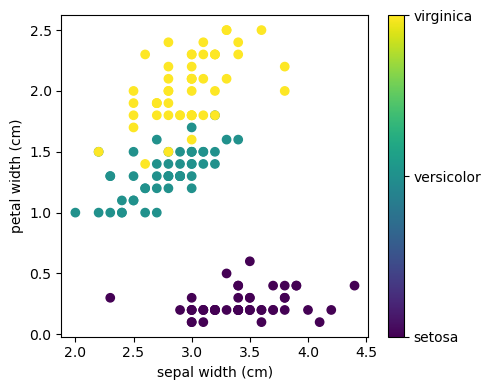

In [3]:
# From: http://scipy-lectures.org/packages/scikit-learn/auto_examples/plot_iris_scatter.html
# The indices of the features that we are plotting
x_index = 1
y_index = 3

# this formatter will label the colorbar with the correct target names
formatter = plt.FuncFormatter(lambda i, *args: iris.target_names[int(i)])

plt.figure(figsize=(5, 4))
plt.scatter(iris.data[:, x_index], iris.data[:, y_index], c=iris.target)
plt.colorbar(ticks=[0, 1, 2], format=formatter)
plt.xlabel(iris.feature_names[x_index])
plt.ylabel(iris.feature_names[y_index])

plt.tight_layout()
plt.show()

## Classification: k nearest neighbours: kNN

K nearest neighbors (kNN) is one of the simplest learning strategies: given a new, unknown observation, look up in your reference database which ones have the closest features and assign the predominant class. Let’s try it out on our iris classification problem:

In [4]:
# Get the data and target
from sklearn import neighbors
iris = load_iris()
X, y = iris.data, iris.target

In [5]:
# Instantiate the kNN model
knn = neighbors.KNeighborsClassifier(n_neighbors=1)
knn.fit(X, y)
# What kind of iris has 3cm x 5cm sepal and 4cm x 2cm petal?
print(iris.target_names[knn.predict([[3, 5, 4, 2]])])

['virginica']


And that's it! Our model, "knn" is now a trained classifier.

We can plot our class boundaries for our kNN classifier (from http://scipy-lectures.org/packages/scikit-learn/auto_examples/plot_iris_knn.html)

(np.float64(4.180808080808081),
 np.float64(8.019191919191918),
 np.float64(1.8868686868686868),
 np.float64(4.513131313131313))

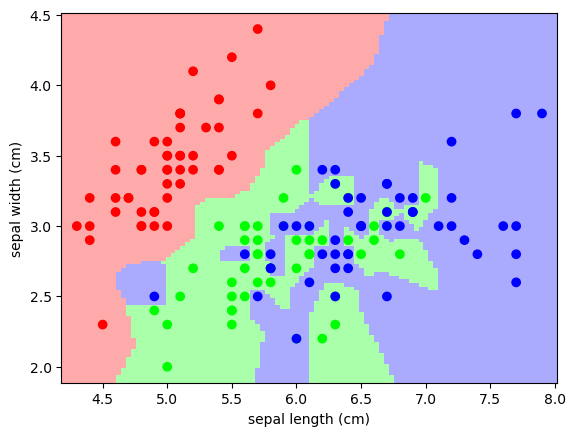

In [6]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn import neighbors, datasets
from matplotlib.colors import ListedColormap

# Create color maps for 3-class classification problem, as with iris
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

iris = datasets.load_iris()
X = iris.data[:, :2]  # we only take the first two features. We could
                    # avoid this ugly slicing by using a two-dim dataset
y = iris.target

knn = neighbors.KNeighborsClassifier(n_neighbors=1)
knn.fit(X, y)

x_min, x_max = X[:, 0].min() - .1, X[:, 0].max() + .1
y_min, y_max = X[:, 1].min() - .1, X[:, 1].max() + .1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                        np.linspace(y_min, y_max, 100))
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.figure()
plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

# Plot also the training points
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold)
plt.xlabel('sepal length (cm)')
plt.ylabel('sepal width (cm)')
plt.axis('tight')

## Classification: Logistic Regression

Let's look at a different classifier: Logistic Regression (despite its name, it does classification)

In [7]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression

iris = load_iris()
X, y = iris.data, iris.target

logit = LogisticRegression(max_iter=200)
logit.fit(X, y)

prediction = logit.predict([[3, 5, 4, 2]])
print(f"Predicted Iris species: {iris.target_names[prediction][0]}")

Predicted Iris species: setosa


# Model Evaluation

## Dataset splitting

Sklearn provides us with many useful tools for manipulating and separating datasets. We'll first look at train_test_split, which splits data into training/test sets.

In [8]:
from sklearn.model_selection import train_test_split
X, y = iris.data, iris.target
print('X shape: {}'.format(X.shape))
print('y shape: {}'.format(y.shape))

X shape: (150, 4)
y shape: (150,)


In [9]:
# Split into training / testing sets. 
# We can specify the proportion we want in each set using the train_size and/or test_size parameters
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.6, test_size=0.4)
print('X_train shape: {}'.format(X_train.shape))
print('X_test shape: {}'.format(X_test.shape))
print('y_train shape: {}'.format(y_train.shape))
print('y_test shape: {}'.format(y_test.shape))

X_train shape: (90, 4)
X_test shape: (60, 4)
y_train shape: (90,)
y_test shape: (60,)


We now have two sets: one set we use to optimize our models, and another set to evaluate how they perform. Let's recreate our previous classifiers.  
Sklearn estimators have the *score* method, which allows us to quickly evaluate the model performance on a particular dataset:

Try the following and rerun the previous cells:  
 1) Modify the "n_neighbors" parameter for the kNN classifier  
 2) Change the "train_size" and "test_size" parameters for the data split (they must sum to <= 1)  
 3) Add "stratify=y" to train_test_split so that the labels are balanced in the training and test sets  
 4) *Do nothing and just rerun them*  



Your model performance depends on the type of model you select and how much data is available for training/evaluation. The fourth point highlights something which is deceptively simple: your model performance also depends on which data points are present in your training and validation sets.  
  
The problem is similar when delving into model *hyperparameters*. Hyperparameters are parameters that are not directly optimized by the data, but that can have a huge impact on model performance. Hyperparameters are determined either by heuristic domain-specific information acquisition ("guessing") or preferably cross-validation.

In [10]:
# from sklearn.model_selection import train_test_split
# X, y = iris.data, iris.target
# print('X shape: {}'.format(X.shape))
# print('y shape: {}'.format(y.shape))


# X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.5, test_size=0.5)
# # 一半用於測試，一半用於訓練 
# # 經過測試，他們之間的比例不宜太高，可能會損失accuaracy

# knn = neighbors.KNeighborsClassifier(n_neighbors=5)
# #將 k 提高
# #好笑的是提得太高反而accuaracy變低
# knn.fit(X_train, y_train)
# logit = LogisticRegression()
# logit.fit(X_train, y_train)

# # 評估
# knn_score = knn.score(X_test, y_test)
# logit_score = logit.score(X_test, y_test)
# print('\n--- 評估結果 ---')
# print('kNN accuracy (k=5): {:.4f}'.format(knn_score))
# print('logit accuracy: {:.4f}'.format(logit_score))

# if knn_score > logit_score:
#     print('kNN performs better!')
# elif knn_score < logit_score:
#     print('logit performs better!')
# else:
#     print('Both models perform equally well!')

In [ ]:

from sklearn.model_selection import cross_val_score

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.5, test_size=0.5, random_state=42, stratify=y)

knn = neighbors.KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

logit = LogisticRegression()
logit.fit(X_train, y_train)


knn_score = cross_val_score(knn, X_train, y_train, cv=5)
logit_score = cross_val_score(logit, X_train, y_train, cv=5)

# 評估
# print('\n--- 評估結果 ---')
# print(f'kNN accuracy (k=5): {knn_score}')
# print(f'logit accuracy: {logit_score}')


# if knn_score > logit_score:
#     print('kNN performs better!')
# elif knn_score < logit_score:
#     print('logit performs better!')
# else:
#     print('Both models perform equally well!')



--- 評估結果 ---
kNN accuracy (k=5): [0.93333333 1.         0.93333333 0.93333333 1.        ]
logit accuracy: [0.93333333 1.         0.93333333 0.93333333 1.        ]


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [ ]:

from sklearn.model_selection import cross_val_score

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.5, test_size=0.5, random_state=45 ,stratify=y)
# 加入random_state seed 與 stratify

knn = neighbors.KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

logit = LogisticRegression()
logit.fit(X_train, y_train)


knn_score = cross_val_score(knn, X_train, y_train, cv=5)
logit_score = cross_val_score(logit, X_train, y_train, cv=5)
# I got it now, cv=5就可以 因為資料室隨機產生的


print('knn_score: {}'.format(knn_score))
print('mean: {}'.format(np.mean(knn_score)))
print('logit_score: {}'.format(logit_score))
print('mean: {}'.format(np.mean(logit_score)))

print('\n')
if(np.mean(knn_score) > np.mean(logit_score)):
    print('knn performs better!')
elif(np.mean(knn_score) < np.mean(logit_score)):
    print('logit performs better!')
else:
    print('Both models perform equally well!')

knn_score: [0.93333333 1.         0.93333333 0.93333333 1.        ]
mean: 0.96
logit_score: [0.93333333 1.         0.93333333 0.93333333 1.        ]
mean: 0.96


Both models perform equally well!


<b>Cross-validation</b> is important for a number of reasons:<br>
<li>Evaluating model performance variability</li>
<li>Determining hyperparameters</li>
<li>Getting reviewers to leave you alone about doing cross-validation</li><br>

<b>K-fold cross-validation (CV)</b> is one example.<br>
To do K-fold CV:<br>
<li>Take your training set</li>
<li>Divide it into K equal subsets (“folds”)</li>
<li>Train on (K-1) folds, and evaluate on the remaining fold</li>
<li>Repeat K times for all folds</li>

Sklearn provides us with convenient functions for doing cross-validation: cross_val_score  
The function defaults to Kfold CV, but other methods are available through sklearn.model_selection

In [ ]:
# Import cross validation function:
from sklearn.model_selection import cross_val_score
# Create the classifier:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.6, test_size=0.4)
logit = LogisticRegression()
logit_scores = cross_val_score(logit, X_train, y_train, cv=5)
print('Logit cross-validation scores: {}'.format(logit_scores))
print('Mean: {}'.format(np.mean(logit_scores)))
knn = neighbors.KNeighborsClassifier(n_neighbors=1)
knn_scores = cross_val_score(knn, X_train, y_train, cv=5)
print('knn cross-validation scores: {}'.format(knn_scores))
print('Mean: {}'.format(np.mean(knn_scores)))

/home/william/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logit cross-validation scores: [1.         1.         0.88888889 0.94444444 1.        ]
Mean: 0.9666666666666666
knn cross-validation scores: [1.         0.88888889 0.94444444 0.94444444 1.        ]
Mean: 0.9555555555555555


# Model Complexity

## Bias / Variance Tradeoff

__Model complexity__ refers to the number of tunable parameters in a model. More complex models are able to represent more complicated relationships between the input and output. 

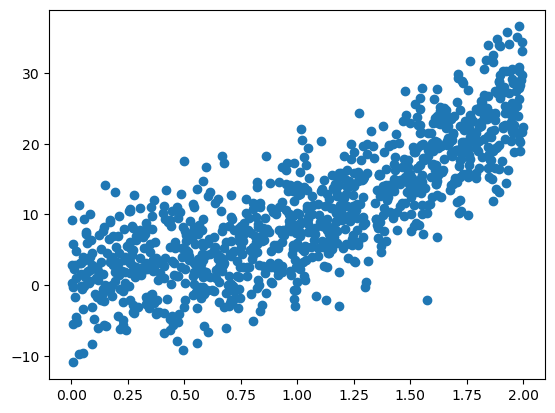

In [ ]:
# From: http://scipy-lectures.org/packages/scikit-learn/auto_examples/plot_bias_variance.html
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
# Generate some synthetic data
def generating_func(x, err=5):
    return np.random.normal(np.power(x+1, 3), err)
X = 2*np.random.random(1000)
y = generating_func(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.5)
plt.figure()
plt.scatter(X, y)

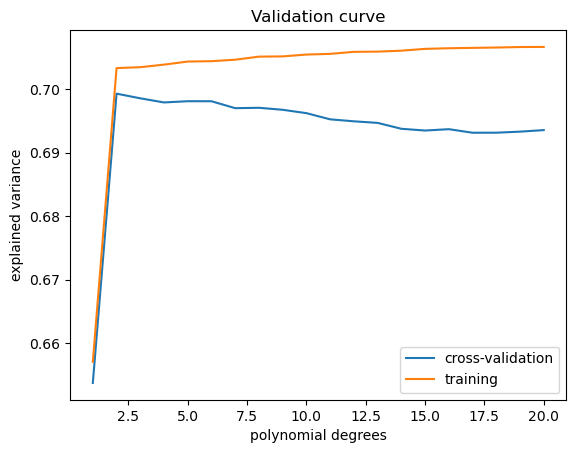

In [ ]:
# Fit polynomials of increasing degrees:
from sklearn.model_selection import validation_curve
degrees = np.arange(1, 21)
model = make_pipeline(PolynomialFeatures(), LinearRegression())

# Vary the "degrees" on the pipeline step "polynomialfeatures"
train_scores, validation_scores = validation_curve(
                model, X[:, np.newaxis], y,
                param_name='polynomialfeatures__degree',
                param_range=degrees)

# Plot the mean train score and validation score across folds
plt.plot(degrees, validation_scores.mean(axis=1), label='cross-validation')  
plt.plot(degrees, train_scores.mean(axis=1), label='training')  
plt.legend(loc='best') 
plt.xlabel('polynomial degrees')
plt.ylabel('explained variance')
plt.title('Validation curve');

The plot is typical for machine learning models, and demonstrates the bias/variance tradeoff. The training performance (orange) peaks at a value, then decreases, indicating that the complex models are overfitting the training data.

**Bias error** refers to the error due to incorrect assumptions about the model. For example, fitting a data that follows x^3 using a model that uses x^2 will have some error that can't be improved by additional data.  
**Variance** refers to error caused by variance in the training set; a model whose parameters change significantly with small changes in the training set is susceptible to *overfitting*.  
  
**Task**: In the previous cells, try varying the amount of data, the degree of the polynomial in the generating function, and the error on the data to see the effect of these factors.

Text(0.5, 1.0, 'Validation curve')

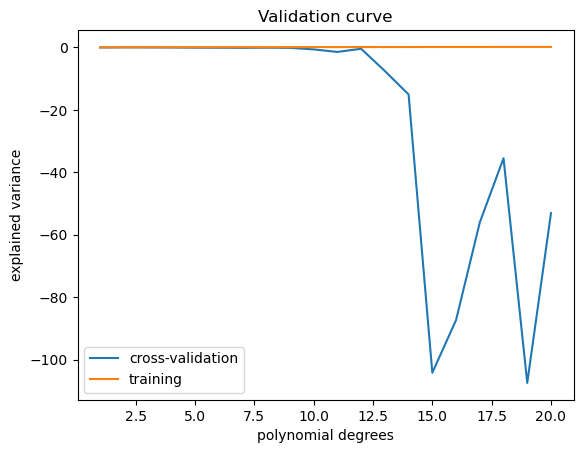

In [ ]:
# From: http://scipy-lectures.org/packages/scikit-learn/auto_examples/plot_bias_variance.html
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
# Generate some synthetic data
def generating_func(x, err=40):
    return np.random.normal(np.power(x+1, 3), err)
# 低誤差 (err=1)：資料點看起來很漂亮，分數高
# 高誤差 (err=40)：分數很糟，甚至到負數


X = 2*np.random.random(100)
# 數據少 (N=10)：Overfittin嚴重。Training score高，但Validation 很低
# 數據多 (N=1000)：跑好久喔，Training score變得很低


y = generating_func(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.5)
# plt.figure()
# plt.scatter(X, y)

# Fit polynomials of increasing degrees:
from sklearn.model_selection import validation_curve
degrees = np.arange(1, 21)
model = make_pipeline(PolynomialFeatures(), LinearRegression())

# Vary the "degrees" on the pipeline step "polynomialfeatures"
train_scores, validation_scores = validation_curve(
                model, X[:, np.newaxis], y,
                param_name='polynomialfeatures__degree',
                param_range=degrees)

# Plot the mean train score and validation score across folds
plt.plot(degrees, validation_scores.mean(axis=1), label='cross-validation')  
plt.plot(degrees, train_scores.mean(axis=1), label='training')  
plt.legend(loc='best') 
plt.xlabel('polynomial degrees')
plt.ylabel('explained variance')
plt.title('Validation curve')

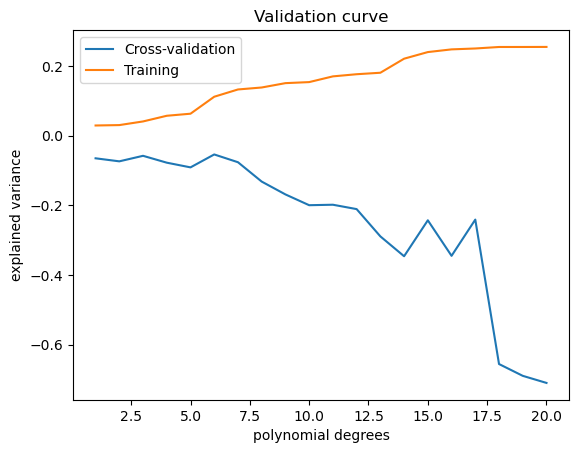

In [ ]:
import random
from sklearn.model_selection import validation_curve, KFold

def generating_func(x, err=40):
    return np.random.normal(np.power(x+1, 3), err)
# 低誤差 (err=1)：資料點看起來很漂亮，分數高
# 高誤差 (err=40)：分數很糟，甚至到負數

X = 2*np.random.random(100)
# 數據少 (N=10)：Overfittin嚴重。Training score高，但Validation 很低
# 數據多 (N=1000)：跑好久喔，Training score變得很低
y = generating_func(X)

# degrees = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]
degrees = np.arange(1, 21)
model = make_pipeline(PolynomialFeatures(), LinearRegression())

train_scores, validation_scores = validation_curve(
    model, X[:, np.newaxis], y,
    param_name='polynomialfeatures__degree',
    param_range=np.arange(1, 21),
    cv=KFold(n_splits=5, shuffle=True, random_state=random.randint(1, 100)), 
    # 建立Cross Validation SEED為1-100隨機整數
    # https://chioujryu.medium.com/k-fold-cross-validation-%E4%BA%A4%E5%8F%89%E9%A9%97%E8%AD%89-%E5%88%86%E5%89%B2%E8%A8%93%E7%B7%B4%E9%9B%86%E5%92%8C%E6%B8%AC%E8%A9%A6%E9%9B%86-2526f5519a0f
)

plt.plot(degrees, validation_scores.mean(axis=1), label='Cross-validation')
plt.plot(degrees, train_scores.mean(axis=1), label='Training')
plt.legend(loc='best') 
plt.xlabel('polynomial degrees')
plt.ylabel('explained variance')
plt.title('Validation curve');

## Regularization

Regularization is a way to limit model complexity to what is helpful. This is done to avoid over-fitting and increase the interpretability of the model. It balances model performance with restrictions on model parameters.

[Ridge regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html) uses linear regression (as before) along with a ridge regularizer (l2 loss on the weights)

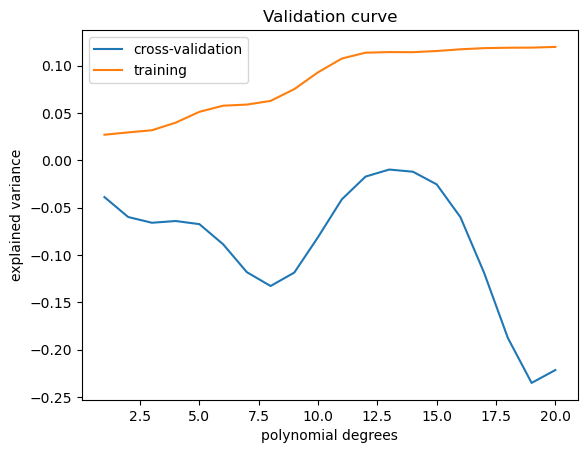

In [ ]:
from sklearn.linear_model import Ridge
degrees = np.arange(1, 21)
model = make_pipeline(PolynomialFeatures(), Ridge(alpha=1))

# Vary the "degrees" on the pipeline step "polynomialfeatures"
train_scores, validation_scores = validation_curve(
                model, X[:, np.newaxis], y,
                param_name='polynomialfeatures__degree',
                param_range=degrees)
# Plot the mean train score and validation score across folds
plt.plot(degrees, validation_scores.mean(axis=1), label='cross-validation')  
plt.plot(degrees, train_scores.mean(axis=1), label='training')  
plt.legend(loc='best') 
plt.xlabel('polynomial degrees')
plt.ylabel('explained variance')
plt.title('Validation curve');